# Data Exploration notebook 

## Workflow 

1. Setup + data laden
2. Data summary
3. Missingness-analyse
4. Featureverdelingen
5. Tijd-tot-sepsis plot
6. Sequentieverdeling
7. Conlusies

## 1. Setup en data inladen 

In [2]:
# set data path 

from pathlib import Path 

DATA_PATH_A = Path.home() / "Datasets" / "Physio2019_Sepsis" / "Dataset_A"
DATA_PATH_B = Path.home() / "Datasets" / "Physio2019_Sepsis" / "Dataset_B"


In [ ]:
import glob
import pandas as pd 
path_str = str(DATA_PATH_A) + "/*.psv"

files = glob.glob(path_str) # list of pathnames

dfs = []
for f in files: 
    df = pd.read_csv(f, sep='|') # load each file into a df
    df['patient_id'] = Path(f).stem # create extra column with pt id #
    dfs.append(df) # append de df to list of dfs

data = pd.concat(dfs, ignore_index=True) # concatenate the list of dfs into one

## 2. Data Summary

In [ ]:
data.info() # rough prospect of missings , dtypes and columns

<class 'pandas.DataFrame'>
RangeIndex: 790215 entries, 0 to 790214
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HR                729026 non-null  float64
 1   O2Sat             695136 non-null  float64
 2   Temp              266901 non-null  float64
 3   SBP               670014 non-null  float64
 4   MAP               709357 non-null  float64
 5   DBP               409918 non-null  float64
 6   Resp              712957 non-null  float64
 7   EtCO2             0 non-null       float64
 8   BaseExcess        82381 non-null   float64
 9   HCO3              63617 non-null   float64
 10  FiO2              112155 non-null  float64
 11  pH                90615 non-null   float64
 12  PaCO2             69288 non-null   float64
 13  SaO2              39160 non-null   float64
 14  AST               11820 non-null   float64
 15  BUN               64476 non-null   float64
 16  Alkalinephos      11532 non-nul

In [9]:
# sneakpeak 

data.head(5)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,80.0,100.0,36.50,121.00,58.0,41.00,13.5,NaN,1.0,25.0,...,223.0,160.0,77.27,1,0.0,1.0,-69.14,3,0,p014977
1,76.0,100.0,36.25,113.25,61.0,41.50,12.0,NaN,1.0,25.0,...,NaN,NaN,77.27,1,0.0,1.0,-69.14,4,0,p014977
2,80.0,100.0,36.25,132.75,71.5,46.25,12.0,NaN,NaN,NaN,...,NaN,NaN,77.27,1,0.0,1.0,-69.14,5,0,p014977
3,78.0,100.0,36.10,103.50,58.0,43.00,12.0,NaN,-3.0,NaN,...,NaN,NaN,77.27,1,0.0,1.0,-69.14,6,0,p014977
4,74.0,100.0,36.00,128.75,69.5,44.50,12.5,NaN,-3.0,NaN,...,NaN,NaN,77.27,1,0.0,1.0,-69.14,7,0,p014977


In [ ]:
# descriptive statistics (non-grouped)
data.describe()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,HR_delta
count,729026.000000,695136.000000,266901.000000,670014.000000,709357.000000,409918.000000,712957.00000,0.0,82381.000000,63617.000000,...,6030.000000,51499.000000,790215.000000,790215.000000,404050.000000,404050.000000,790207.000000,790215.000000,790215.000000,679804.000000
mean,84.985264,97.265688,37.026737,120.962359,78.767345,59.985809,18.77346,NaN,-0.647537,24.094476,...,292.251642,199.617841,63.016780,0.577721,0.507101,0.492899,-52.025757,27.198518,0.021685,-0.046943
std,16.940431,2.908794,0.780317,21.520567,15.044038,12.572771,5.39575,NaN,4.286641,4.396192,...,158.632042,109.244146,16.133632,0.493923,0.499950,0.499950,155.864937,28.190940,0.145654,7.632880
min,20.000000,20.000000,20.900000,22.000000,20.000000,20.000000,1.00000,NaN,-32.000000,0.000000,...,34.000000,5.000000,18.110000,0.000000,0.000000,0.000000,-3710.660000,1.000000,0.000000,-165.000000
25%,73.000000,96.000000,36.560000,105.000000,68.000000,51.000000,15.00000,NaN,-3.000000,22.000000,...,184.000000,127.000000,52.740000,0.000000,0.000000,0.000000,-38.090000,11.000000,0.000000,-3.000000
50%,84.000000,98.000000,37.060000,118.500000,77.000000,58.500000,18.00000,NaN,0.000000,24.000000,...,250.000000,181.000000,65.250000,1.000000,1.000000,0.000000,-2.600000,21.000000,0.000000,0.000000
75%,96.000000,99.500000,37.550000,134.000000,87.330000,67.000000,22.00000,NaN,1.000000,27.000000,...,356.750000,247.000000,75.890000,1.000000,1.000000,1.000000,-0.020000,35.000000,0.000000,3.000000
max,280.000000,100.000000,42.220000,281.000000,300.000000,298.000000,69.00000,NaN,100.000000,55.000000,...,1760.000000,1783.000000,89.000000,1.000000,1.000000,1.000000,23.990000,336.000000,1.000000,169.000000


In [ ]:
# Basic information

n_patients = data["patient_id"].nunique()
n_features = len(list(data.columns))
grouped = data.groupby('patient_id').agg(
    sepsis=('SepsisLabel', 'max')
)
sepsis_percentage = grouped['sepsis'].mean() * 100

print(f" The total patient count is: {n_patients}")
print(f" The total number of features is: {n_features}")
print(f" The percentage of sepsis patients is: {sepsis_percentage:.2f} %")



 The total patient count is: 20336
 The total number of features is: 42
 The percentage of sepsis patients is: 8.80 %


In [96]:
# Identification of sepsis and non - sepsis patients 

sepsis_patients = list(data[data["SepsisLabel"] == 1]["patient_id"].unique())
non_sepsis_patients = [patient for patient in data.patient_id.unique() if patient not in sepsis_patients]

# print example 

print(f"The first 5 sepsis patients are {sepsis_patients[:5]}")
print(f"The first 5 non sepsis patients are {non_sepsis_patients[:5]}")

The first 5 sepsis patients are ['p016806', 'p006368', 'p013003', 'p018630', 'p016609']
The first 5 non sepsis patients are ['p014977', 'p000902', 'p009098', 'p008386', 'p018195']


## 3. Missingness-analyse

HR                    7.743336
O2Sat                12.032042
Temp                 66.224255
SBP                  15.211177
MAP                  10.232405
DBP                  48.125763
Resp                  9.776833
EtCO2               100.000000
BaseExcess           89.574863
HCO3                 91.949406
FiO2                 85.807027
pH                   88.532868
PaCO2                91.231753
SaO2                 95.044387
AST                  98.504205
BUN                  91.840702
Alkalinephos         98.540650
Calcium              95.024392
Chloride             91.676063
Creatinine           93.357884
Bilirubin_direct     99.850420
Glucose              87.768392
Lactate              96.565112
Magnesium            92.219712
Phosphate            94.951247
Potassium            89.137640
Bilirubin_total      98.773372
TroponinI            99.877881
Hct                  88.223711
Hgb                  91.164303
PTT                  95.152459
WBC                  92.489639
Fibrinog

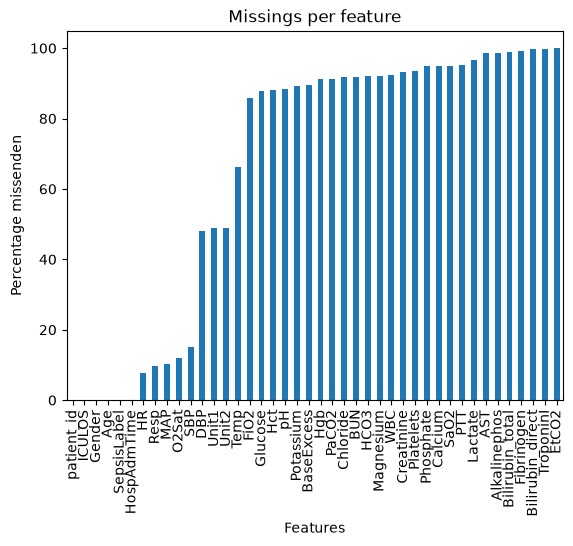

In [6]:
import matplotlib.pyplot as plt
missingness_set = data.isna().mean() *100

plt.figure() 
plt.xlabel('Features')
plt.ylabel('Percentage missenden')
plt.title('Missings per feature')
missingness_set.sort_values().plot(kind='bar');

print(missingness_set)



## 4. distribution features sepsis vs non-sepsis

In [16]:
data.columns 

Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
       'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id'],
      dtype='str')

In [73]:

# glob variable handig
SOFA_features = ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'FiO2', 'SaO2', 'Bilirubin_total','Platelets','ICULOS', 'Creatinine', 'Lactate']

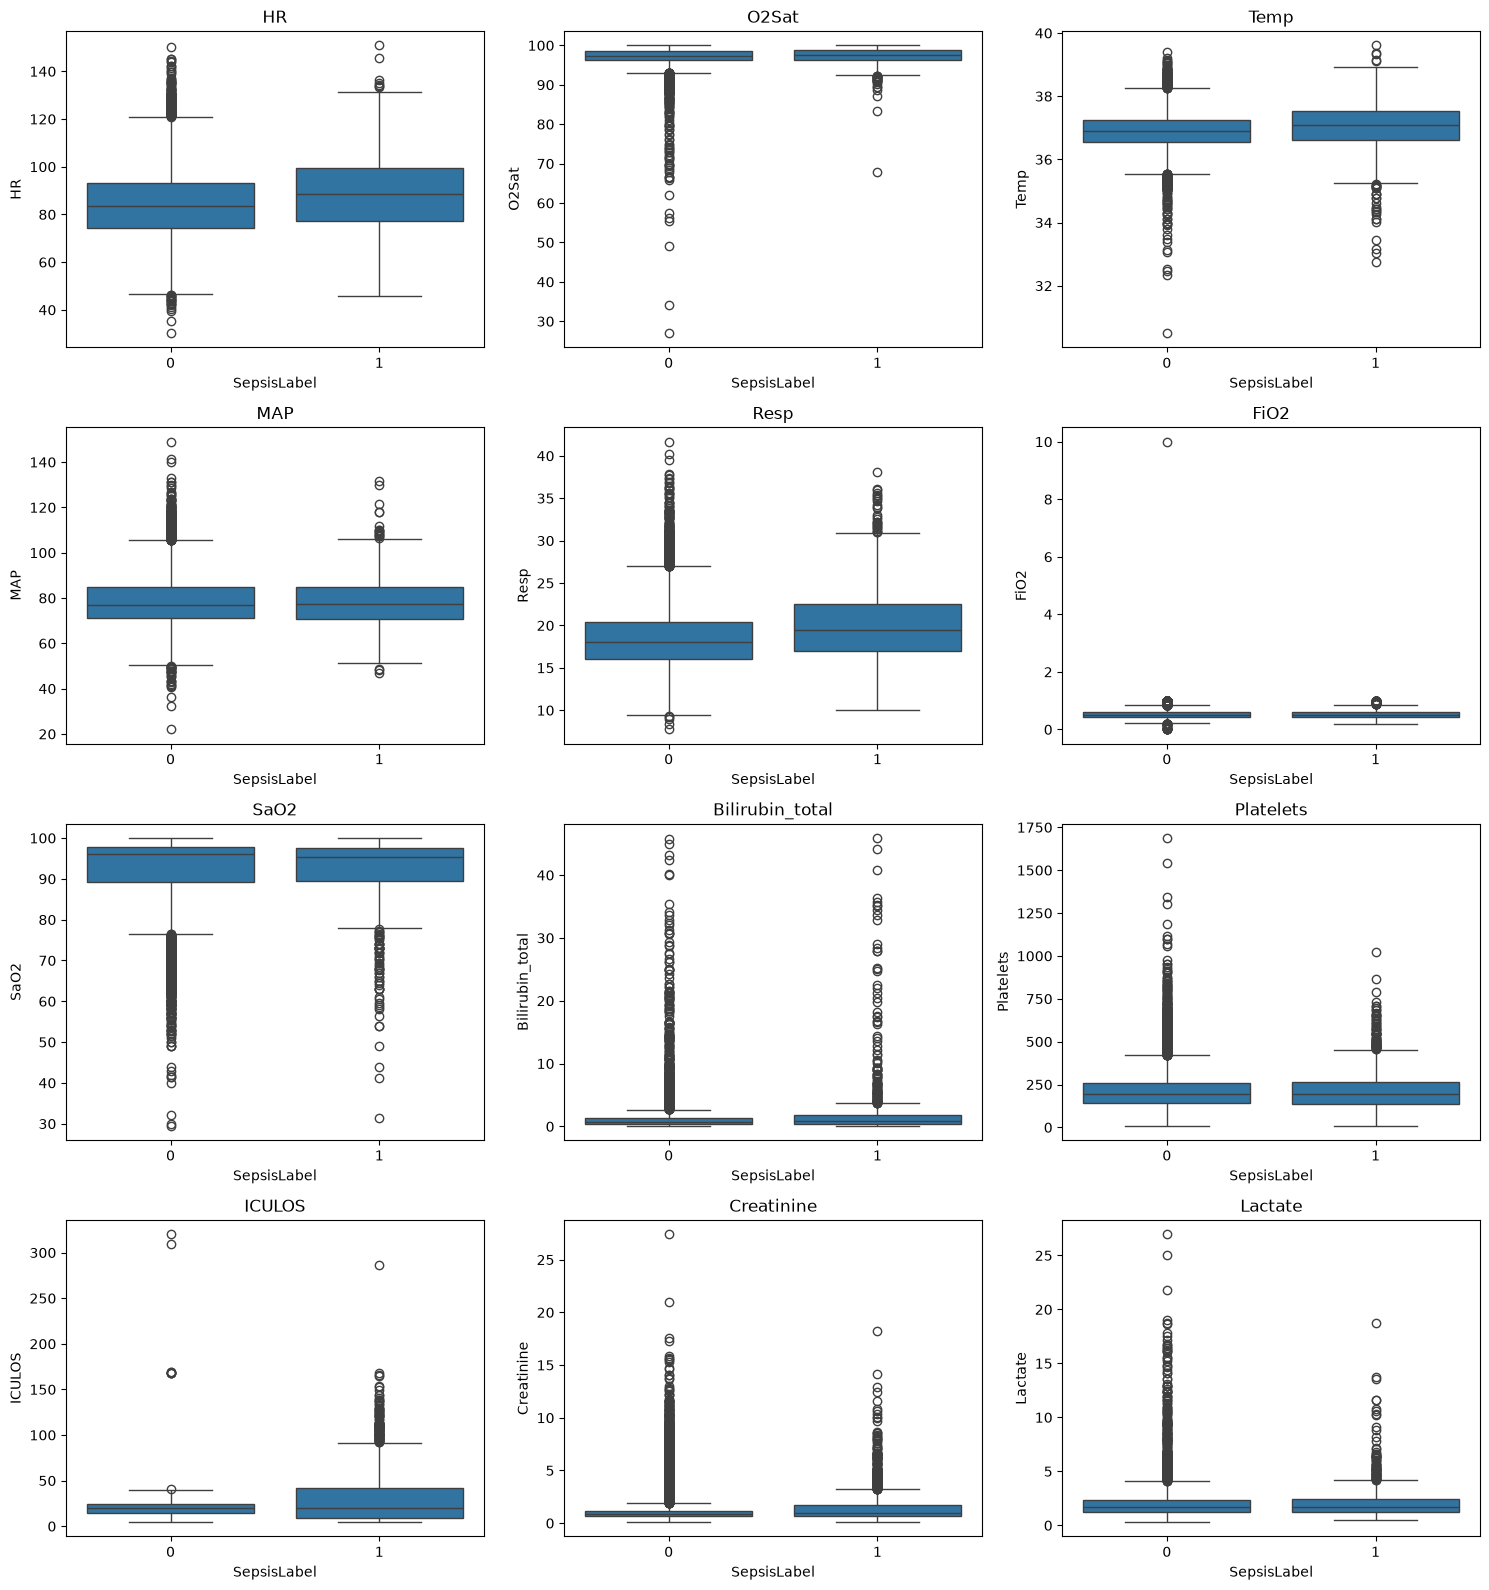

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 

features = list(data.columns)

grouped_df = data.groupby("patient_id").agg({
    **{col: "mean" for col in data.columns if col not in ["patient_id", "SepsisLabel"]},
    "SepsisLabel": "max"
}).reset_index() # create grouped df with mean aggregate 


fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for ax, feature in zip(axes.flat, SOFA_features): # Create a plot with boxplots for every essential feature, split sepsis label
    sns.boxplot(
        data=grouped_df,
        x='SepsisLabel',
        y=feature,
        ax=ax
        )
    ax.set_title(feature)

plt.tight_layout()
plt.show()


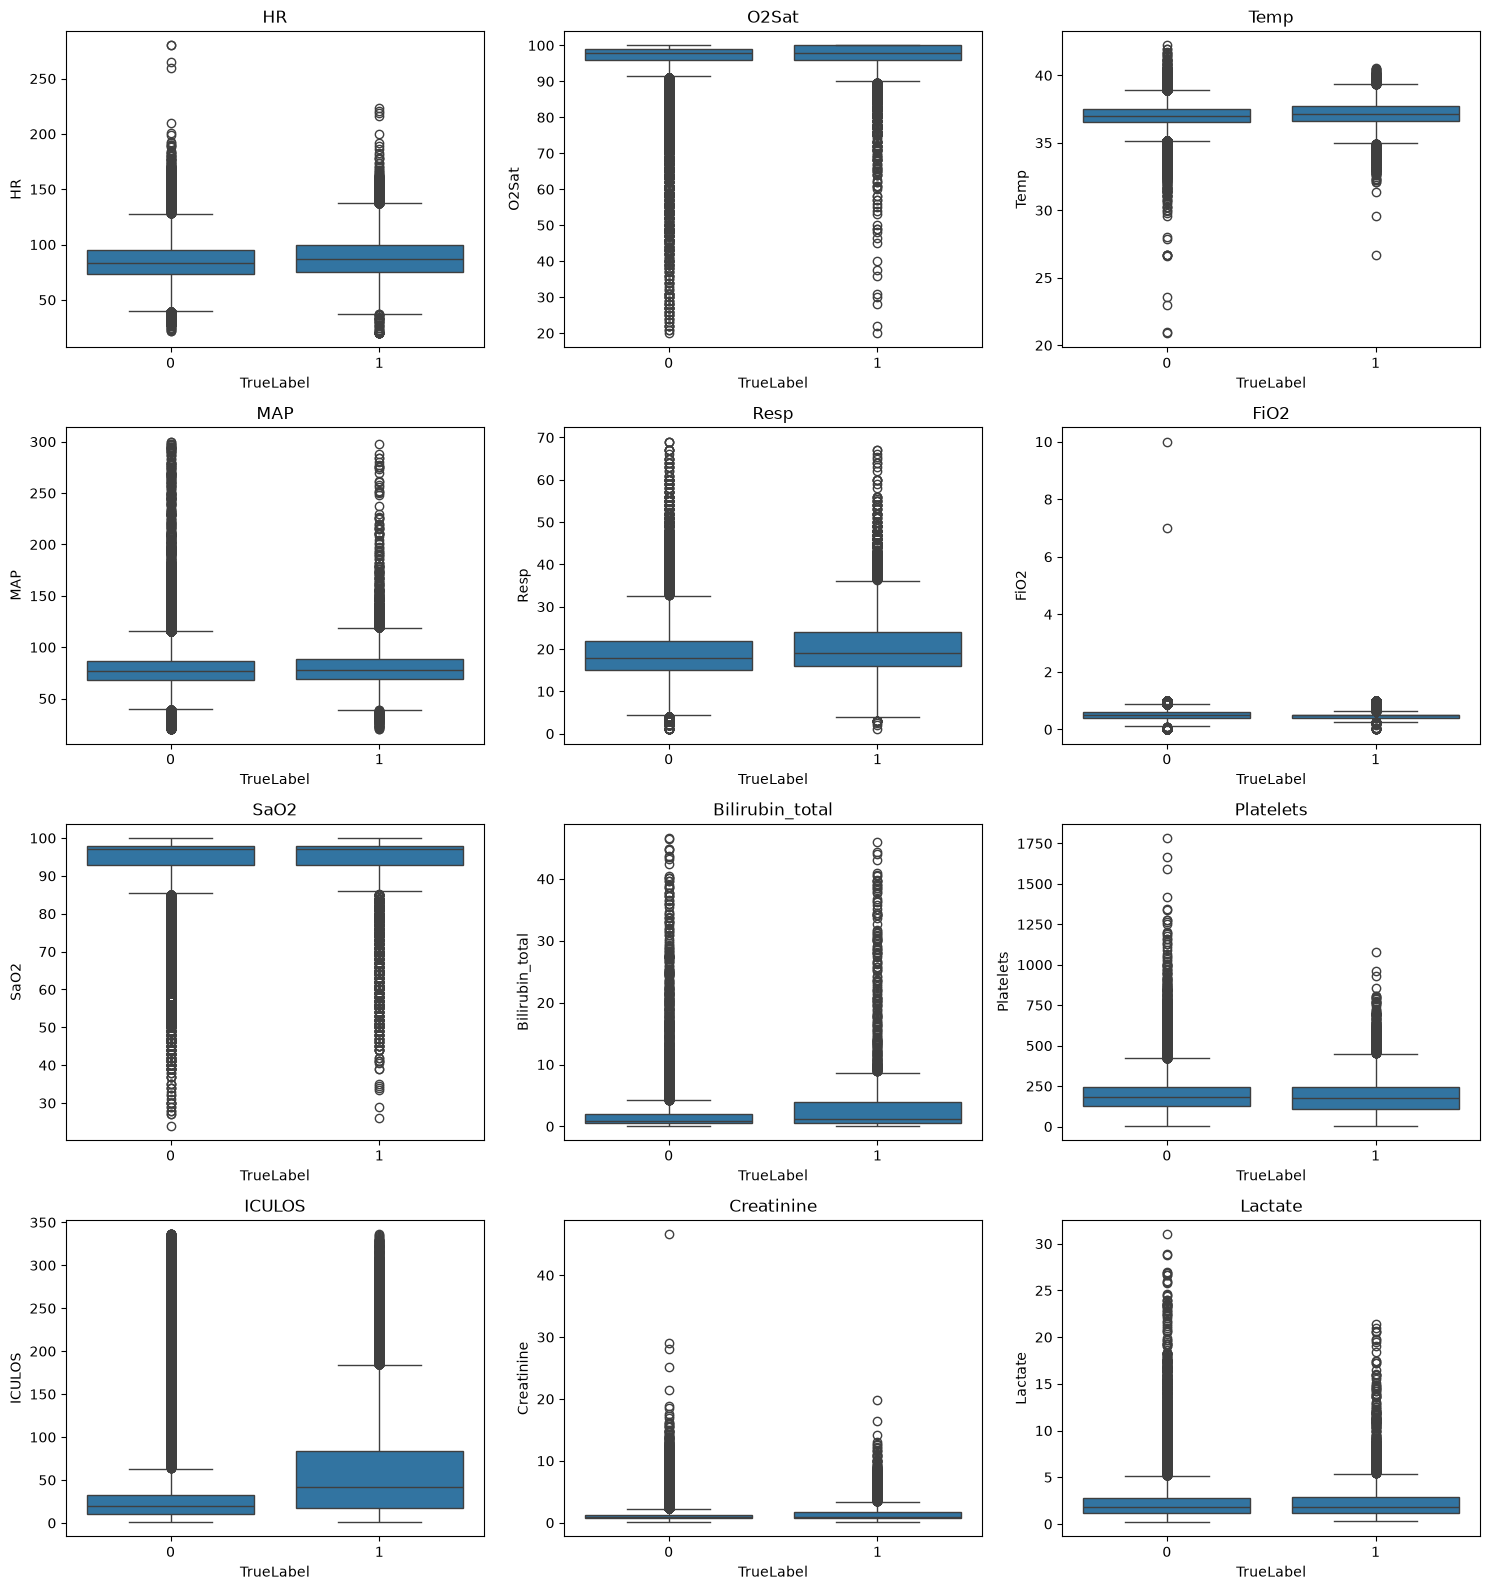

In [100]:
# another plot taking into account the distribution of all data (instead of just the mean)
import numpy as np
data["TrueLabel"] = np.where(data["patient_id"].isin(sepsis_patients), 
                             1,
                             0)

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for ax, feature in zip(axes.flat, SOFA_features): 
    sns.boxplot(data=data,
                x="TrueLabel",
                y=feature,
                ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()


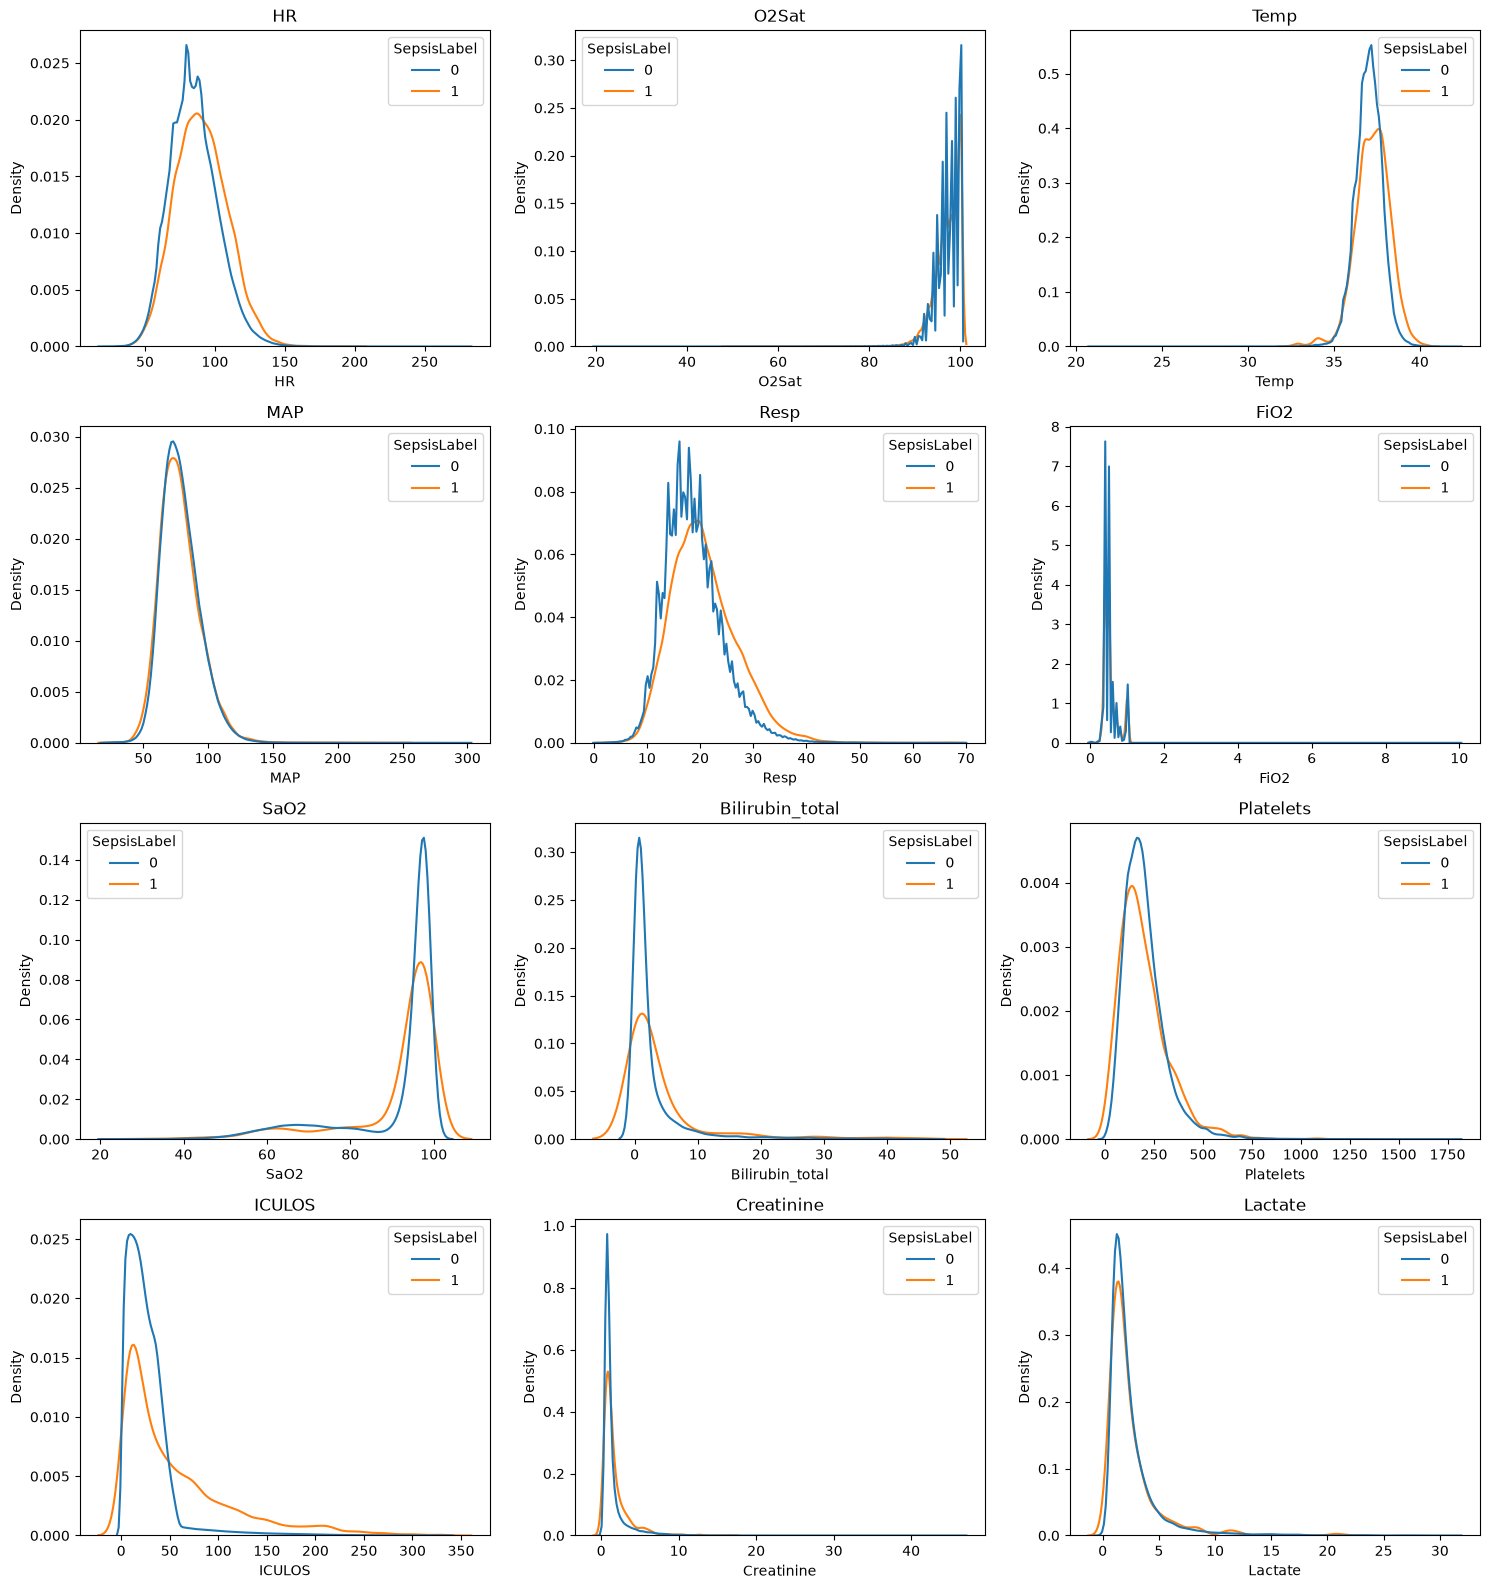

In [ ]:
# Distribution per group, full dataset, visualized by KDE plots
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, feature in zip(axes.flat, SOFA_features): 
    sns.kdeplot(
        data=data,
        x=feature,
        hue="SepsisLabel",
        ax=ax,
        common_norm=False)
    ax.set_title(feature)
plt.tight_layout()
plt.show()
    

In [ ]:
# Sepsis vs Non sepsis average values
grouped_mean = grouped_df.groupby("SepsisLabel").mean(numeric_only=True).T
grouped_mean.columns = ["Sepsis", "non_Sepsis"]
grouped_mean

,Sepsis,non_Sepsis
HR,84.125952,88.930885
O2Sat,97.186790,97.349462
Temp,36.900436,37.053520
SBP,120.315672,119.507509
MAP,78.512572,78.072708
DBP,60.129853,60.580638
Resp,18.450659,20.047730
EtCO2,NaN,NaN
BaseExcess,-0.403617,-0.200399
HCO3,24.452295,23.909380


## 5. Tijd - tot - sepsis plot 

In [19]:
# alle t-sepsis tijdstippen bepalen 

sepsis_only = data[data["SepsisLabel"] == 1] # filter alleen op patienten die sepsis hebben gehad 

t_sepsis_series = sepsis_only.groupby("patient_id")["ICULOS"].min() # pak alleen minimale waarde van ICULOS voor alle patienten

t_sepsis_series = t_sepsis_series.rename("t_sepsis_hour") # geef passende naam 

t_sepsis_series.head(5)

patient_id
p000009    249
p000011     26
p000015      6
p000018    126
p000022     14
Name: t_sepsis_hour, dtype: int64

In [ ]:
# voeg nieuwe data toe aan originele dataset

sepsis_only = data.merge(
    t_sepsis_series, 
    on="patient_id", 
    how="inner"
)

sepsis_only(50)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,t_sepsis_hour
0,110.0,100.0,35.90,110.0,83.0,70.0,14.0,NaN,-4.0,20.0,...,NaN,66.36,1,0.0,1.0,-162.76,6,0,p016806,51
1,110.0,100.0,36.20,118.0,90.0,76.0,14.0,NaN,NaN,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,7,0,p016806,51
2,102.0,100.0,36.50,100.0,76.0,63.0,14.0,NaN,-4.0,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,8,0,p016806,51
3,101.0,100.0,36.10,121.0,87.0,71.0,15.0,NaN,-4.0,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,9,0,p016806,51
4,100.0,100.0,36.00,129.0,90.0,72.0,16.0,NaN,NaN,21.0,...,105.0,66.36,1,0.0,1.0,-162.76,10,0,p016806,51
5,91.0,100.0,36.00,114.0,79.0,65.0,16.0,NaN,-4.0,21.0,...,NaN,66.36,1,0.0,1.0,-162.76,11,0,p016806,51
6,89.0,100.0,36.10,98.0,71.0,59.0,16.0,NaN,-4.0,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,12,0,p016806,51
7,103.0,100.0,36.60,107.0,80.0,67.0,16.0,NaN,NaN,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,13,0,p016806,51
8,107.0,100.0,36.70,131.0,92.0,73.0,15.0,NaN,NaN,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,14,0,p016806,51
9,112.0,100.0,36.80,132.0,90.0,71.0,17.0,NaN,NaN,NaN,...,NaN,66.36,1,0.0,1.0,-162.76,15,0,p016806,51


In [24]:
# creer nieuwe variabele relative_hour 

sepsis_only["relative_hour"] = sepsis_only["ICULOS"] - sepsis_only["t_sepsis_hour"]

sepsis_only.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,t_sepsis_hour,relative_hour
0,110.0,100.0,35.9,110.0,83.0,70.0,14.0,NaN,-4.0,20.0,...,66.36,1,0.0,1.0,-162.76,6,0,p016806,51,-45
1,110.0,100.0,36.2,118.0,90.0,76.0,14.0,NaN,NaN,NaN,...,66.36,1,0.0,1.0,-162.76,7,0,p016806,51,-44
2,102.0,100.0,36.5,100.0,76.0,63.0,14.0,NaN,-4.0,NaN,...,66.36,1,0.0,1.0,-162.76,8,0,p016806,51,-43
3,101.0,100.0,36.1,121.0,87.0,71.0,15.0,NaN,-4.0,NaN,...,66.36,1,0.0,1.0,-162.76,9,0,p016806,51,-42
4,100.0,100.0,36.0,129.0,90.0,72.0,16.0,NaN,NaN,21.0,...,66.36,1,0.0,1.0,-162.76,10,0,p016806,51,-41


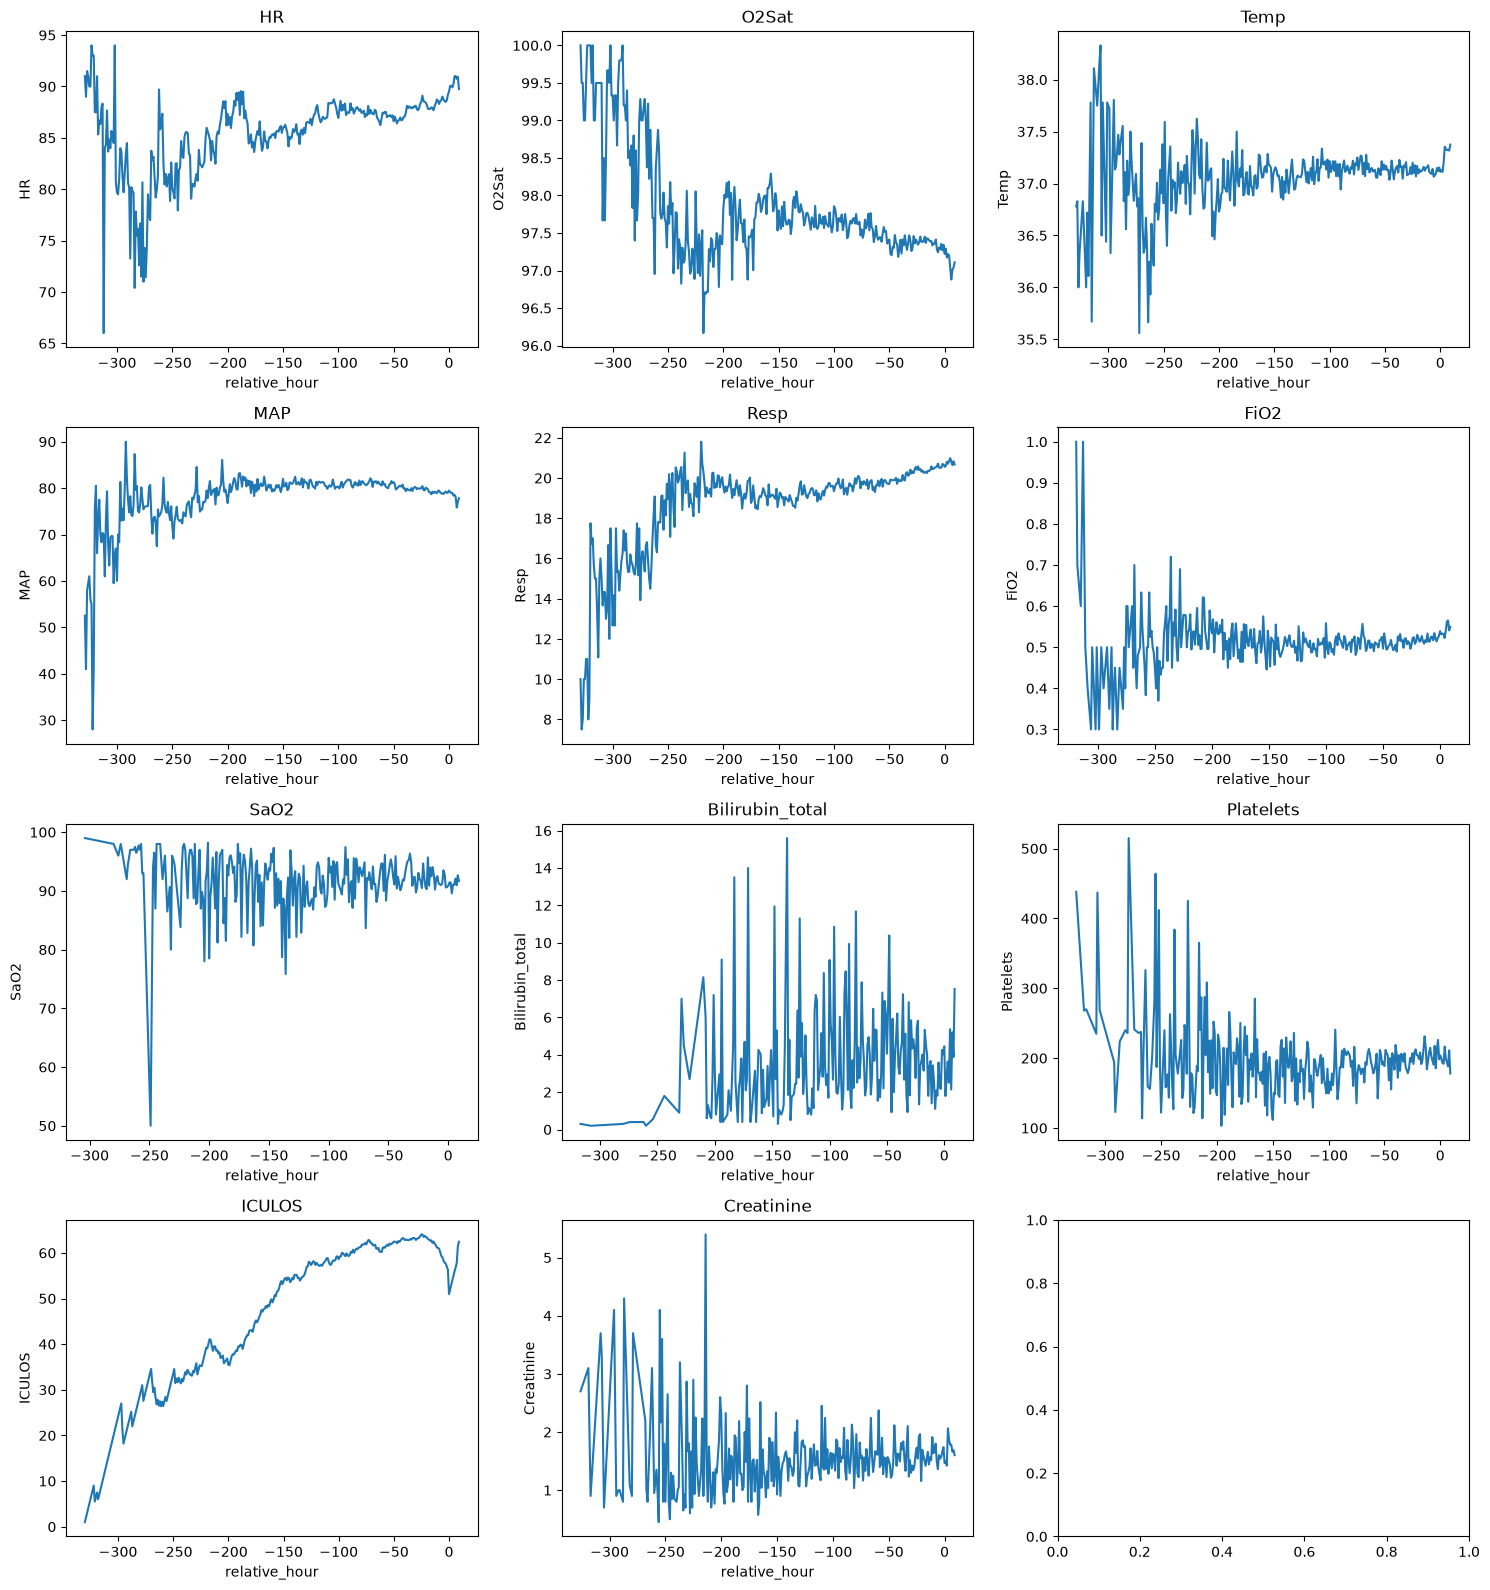

In [39]:
# Creer plots 
import matplotlib.pyplot as plt
mapping_fn = lambda x : sepsis_only.groupby("relative_hour")[x].mean()


fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, feature in zip(axes.flat, SOFA_features):
    sns.lineplot(
        data= mapping_fn(feature).to_frame().reset_index(),
        x= "relative_hour",
        y=feature,
        ax=ax 
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()


## 6. Sequentie analyse 

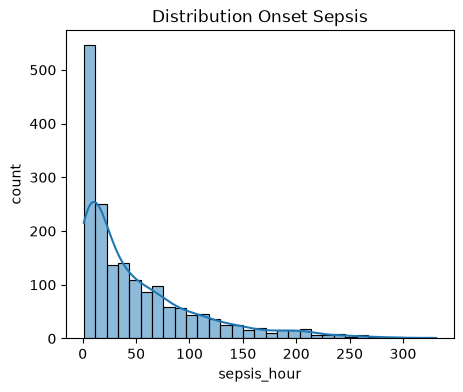

In [150]:
grouped_sepsis_byT = sepsis_only.groupby("patient_id").agg(sepsis_hour = ("t_sepsis_hour", "first")) 

plt.figure(figsize=(5,4))
sns.histplot(data=grouped_sepsis, 
             x= "sepsis_hour",
             kde= True)
plt.xlabel("sepsis_hour")
plt.ylabel("count")
plt.title("Distribution Onset Sepsis")
plt.show()

In [151]:
grouped_sepsis_byT["sepsis_hour"].describe()

count    1790.000000
mean       50.971508
std        57.761143
min         1.000000
25%         8.000000
50%        29.500000
75%        73.000000
max       331.000000
Name: sepsis_hour, dtype: float64

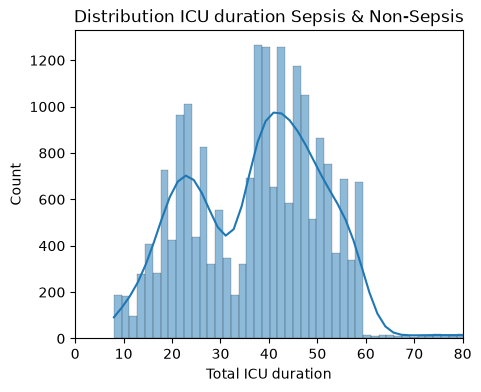

In [56]:
# histogram van verdeling totaal duur LOS (sepsis en non sepsis)

series = data.groupby("patient_id")["ICULOS"].max().rename("TOTAL_ICULOS")
dataframe = series.to_frame().reset_index()


plt.figure(figsize=(5,4))
sns.histplot(data=dataframe, 
             x= "TOTAL_ICULOS",
             kde=True)
plt.xlim(0, 80)
plt.xlabel("Total ICU duration")
plt.ylabel("Count")
plt.title("Distribution ICU duration Sepsis & Non-Sepsis")
plt.show()


In [61]:
dataframe.describe()

,TOTAL_ICULOS
count,20336.000000
mean,39.774194
std,22.552482
min,8.000000
25%,26.000000
50%,40.000000
75%,48.000000
max,336.000000


In [142]:
# Percentage sepsis patienten met window voor diagnose = bruikbare data voor training
sepsis_patients_df = data.loc[data["patient_id"].isin(sepsis_patients), ["SepsisLabel", "patient_id"]].reset_index(drop=True)

filt_a = sepsis_patients_df.groupby("patient_id").agg(SepsisLabel = ("SepsisLabel", "first")) # grouped sepsis patients by first sepsis label
non_usable_sepsis = len(list(filt_a.loc[filt_a["SepsisLabel"] == 1].reset_index()["patient_id"]))
percentage_non_usable =  non_usable_sepsis / len(sepsis_patients) * 100
print(f"{non_usable_sepsis}({percentage_non_usable:.2f}%) sepsis patients are not usable for training...")

203(11.34%) sepsis patients are not usable for training...


In [162]:
EXP_WINDOW_SIZE = list(range(0, 72))

def percentage_calculator(data, window_list):
    usable_percentages = []
    for hour in window_list: 
        filtered_set = data.groupby("patient_id").agg(total_hours_before_sepsis = ("relative_hour", "first"))
        count = len(filtered_set[np.abs(filtered_set["total_hours_before_sepsis"]) > hour])
        percentage = count/len(sepsis_patients) * 100 
        usable_percentages.append(percentage)
    return usable_percentages

percentage_calculator(sepsis_only, EXP_WINDOW_SIZE)

df_temp = pd.DataFrame({"Window_size_h" : EXP_WINDOW_SIZE, "Usable_Percentage": percentage_calculator(sepsis_only, EXP_WINDOW_SIZE)})


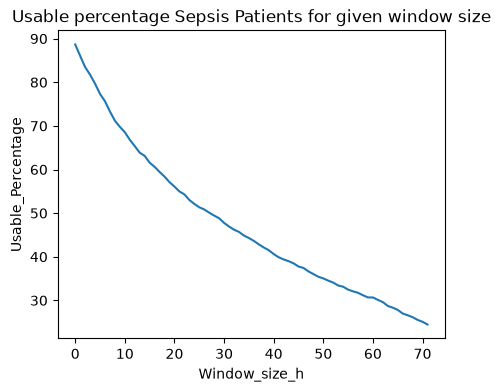

In [164]:
# plot the exp window size 

plt.figure(figsize=(5,4))

sns.lineplot(data=df_temp, 
             x="Window_size_h",
             y="Usable_Percentage")
plt.title("Usable percentage Sepsis Patients for given window size")
plt.show()

# 7. Conclusies

### 7.1 Dataset en doelgroep

We werken met **PhysioNet Challenge 2019 Sepsis, Dataset_A**.

| Kenmerk | Waarde |
|---------|--------|
| Patiënten | 20.336 |
| Tijdstap-regels | 790.215 (uurlijkse metingen) |
| Gemiddelde ICU-duur | ~39 uur per patiënt (mediaan 40, max 336) |
| Sepsis-patiënten | 8,80% (1.790) |

Dit is een sterk geïmbalanceerde classificatietaak. Voor een LSTM-model zijn technieken zoals **class weighting**, **oversampling** of geschikte evaluatiemetrics (bijvoorbeeld **AUROC** en **AUPRC**) noodzakelijk.

Dataset_B staat al klaar in de projectstructuur, maar is nog niet geladen. Deze dataset kan later gebruikt worden voor **externe validatie**.

---

### 7.2 Missingness: niet alle features zijn bruikbaar

De features kunnen grofweg in drie groepen worden verdeeld.

### Goed bruikbaar (<15% missende waarden)

- HR (~8%)
- MAP (~10%)
- Resp (~10%)
- O2Sat (~12%)

### Matig bruikbaar

- SBP (~15%)
- Temp (~66%)
- DBP (~48%)

### Zeer schaars of niet bruikbaar

- EtCO2: **100% missing** → verwijderen
- Lactate (~97%)
- Creatinine (~93%)
- Bilirubin (~99%)
- TroponinI (~99%)
- Fibrinogen (~99%)
- FiO2 (~86%)
- SaO2 (~95%)

Voor een eerste LSTM ligt de focus daarom op de vitale parameters zoals **HR, O2Sat, MAP, Resp, SBP** en eventueel **Temp**. Veel laboratoriumwaarden en SOFA-componenten zijn te incompleet om direct te gebruiken. Imputatie en/of expliciete missingness-indicatoren zijn hiervoor noodzakelijk.

---

### 7.3 Sepsis versus non-sepsis

Op patiëntniveau (gemiddelde over alle uren) zijn de verschillen tussen beide groepen beperkt.

| Feature | Sepsis | Non-sepsis | Verschil |
|---------|--------:|-----------:|---------:|
| HR | 88,9 | 84,1 | +4,8 |
| Resp | 20,1 | 18,5 | +1,6 |
| Creatinine | 1,57 | 1,27 | +0,30 |
| WBC | 13,0 | 11,7 | +1,3 |
| MAP | 78,1 | 78,5 | −0,4 |

Ook leeftijd en geslacht verschillen nauwelijks tussen beide groepen.

Hieruit blijkt dat **statische gemiddelden de klassen slechts beperkt onderscheiden**. Het voorspellende signaal zal daarom waarschijnlijk vooral aanwezig zijn in **temporele veranderingen** voorafgaand aan sepsis. De analyse op basis van `relative_hour` is daarom waarschijnlijk informatiever dan analyses op basis van patiëntgemiddelden.

---

### 7.4 Tijd tot sepsis

| Statistiek | Waarde |
|------------|--------|
| Mediaan sepsis-onset | 30 uur na ICU-opname |
| Patiënten met pre-sepsis uren | 88,7% (1.587 / 1.790) |
| Mediaan pre-sepsis uren | 28 uur |
| Gemiddelde pre-sepsis uren | ~49 uur |

Sepsis-patiënten verblijven gemiddeld langer op de intensive care (**59,5 uur versus 37,9 uur**).

Voor het ontwikkelen van een early warning-model is voldoende observatietijd beschikbaar vóór de eerste sepsisdiagnose. Een voorspellingsvenster van bijvoorbeeld **24 uur vóór onset** lijkt daarom realistisch.

---

### 7.5 Sequentieanalyse

De opnameduur varieert sterk tussen patiënten (tot **336 uur**).

Daarnaast hebben sepsis-patiënten gemiddeld langere en heterogenere trajecten dan non-sepsis-patiënten.

Hierdoor moet de LSTM-pipeline ondersteuning bieden voor:

- variabele sequentielengtes;
- padding en masking;
- patiëntniveau train/validatie/test-splits.

Een willekeurige splitsing op uurniveau moet worden vermeden om datalekken tussen trainings- en testdata te voorkomen.

---

### 7.6 Overwegingen

- Start met een compacte feature-set bestaande uit de belangrijkste vitale parameters.
Ongeveer: goed + matig bruikbaar + (schaarse) sofa relevante variabelen (bilirubine, lactaat, creatinine, gasparameters)
- Verwijder **EtCO2** en zeer schaarse laboratoriumvariabelen uit de eerste modelversie.
- Feature Engineering: 
1. Een **missingness indicator** toevoegen (opvatting = "geen meting is positief") zodat LSTM ook deze patronen kan leren (bijv voor lactaat).
2. Sp02/Fi02 ratio variabele (vervanger voor Pa02/Fi02). 
3. Schok_index = HR/ SBP. 
4. Trends voor belangrijke variabelen ("HR", "MAP", "Resp", "O2Sat", "Temp") zoals delta en rolling mean. 
- Imputatie: Pas **forward-fill** per patiënt toe. Resterende NaN's --> median of gemiddelde.
- Definieer het label als **sepsis X uur vóór onset** (bijvoorbeeld 6, 12 of 24 uur) in plaats van uitsluitend het huidige `SepsisLabel`.
- Maak patiëntniveau train-, validatie- en testsplits met behoud van de sepsisverdeling.
- Gebruik **Dataset_B** uitsluitend als onafhankelijke testset voor externe validatie.

---

## Samenvattende conclusie

De dataset is geschikt voor het ontwikkelen van een **LSTM-gebaseerd early warning-model**. Er zijn voldoende patiënten beschikbaar, de metingen zijn uurlijkse tijdreeksen en er is gemiddeld ongeveer **28 uur observatietijd vóór sepsis-onset** beschikbaar.

De belangrijkste uitdagingen zijn:

- een sterke class imbalance (8,8% sepsis);
- veel missende waarden bij laboratoriumvariabelen;
- beperkte discriminatie op basis van statische patiëntgemiddelden.

Daarom zal de uiteindelijke voorspellende kracht vooral moeten komen uit het leren van **temporele patronen** in vitale functies, in plaats van uit afzonderlijke drempelwaarden van individuele metingen. Een idee hiervan wordt weergegeven in de plot onder **sectie 5: tijd tot sepsis**